# Shells, gases, and media

Compare the physical parts of a bubble model. You drive an uncoated bubble, a lipid-coated contrast agent, and a polymer-shelled agent with the same pulse, and you see how the lipid shell's surface tension changes with the radius. Then you swap the gas law and the surrounding medium.

An equation of motion combines a gas model, a shell model, and a medium model. Each lives in its own module: `jbubble.bubble.gas`, `jbubble.bubble.shell`, and `jbubble.bubble.medium`.

In [ ]:
# Install jbubble on Google Colab, or anywhere it's missing.
import importlib.util

if importlib.util.find_spec("jbubble") is None:
    %pip install --quiet "jbubble[examples]==0.2.0"

In [1]:
import os

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from jbubble import SaveSpec, run_simulation
from jbubble.bubble.gas import PolytropicGas, VanDerWaalsGas
from jbubble.bubble.medium import (
    KelvinVoigtMedium,
    NeoHookeanMedium,
    NewtonianMedium,
    PowerLawMedium,
)
from jbubble.bubble.shell import MarmottantSurfaceTension
from jbubble.bubble.state import BubbleState
from jbubble.pulse import ToneBurst
from jbubble.pulse.shapes import Sine
from jbubble.utils.presets import free_bubble, lipid_bubble, thick_shell_bubble

plt.style.use("jbubble.style.light")
DRIVE = "#8c959f"  # neutral grey for the acoustic drive in the light theme
QUICK = os.environ.get("JBUBBLE_QUICK") == "1"  # smaller sweeps for CI

## Compare three shells

The three presets share the liquid (water), the radius (2 µm), and the pulse (five cycles at 1 MHz and 100 kPa). They differ in the coating:

- `free_bubble` has no shell, only the surface tension of water.
- `lipid_bubble` has a lipid monolayer, as in SonoVue. Its surface tension follows the Marmottant law: zero when the shell buckles under compression, elastic over a narrow range of radii, and the surface tension of water once the shell ruptures under expansion.
- `thick_shell_bubble` has a stiff, viscous polymer shell of finite thickness (the Church model), which damps the motion heavily.

In [2]:
presets = {
    "free bubble": free_bubble(),
    "lipid shell": lipid_bubble(),
    "polymer shell": thick_shell_bubble(),
}
runs = {name: run_simulation(eom, pulse) for name, (eom, pulse) in presets.items()}
for name, run in runs.items():
    R0 = presets[name].eom.R0
    print(
        f"{name:14s} R/R0 from {run.radius.min() / R0:.3f} to {run.radius.max() / R0:.3f}"
    )

free bubble    R/R0 from 0.500 to 1.593
lipid shell    R/R0 from 0.735 to 1.227
polymer shell  R/R0 from 0.989 to 1.013


Evaluate the lipid shell's surface tension law directly. A surface tension law is a `Property`: a function of the bubble state, which you call with a `BubbleState`, here one that holds 600 radii at once. The preset uses `SmoothMarmottantSurfaceTension`, which rounds the corners of the piecewise Marmottant law so that gradients stay smooth. The shaded band marks the radii that the lipid bubble reaches in the simulation. Most of that range lies outside the narrow elastic region between buckling and rupture.

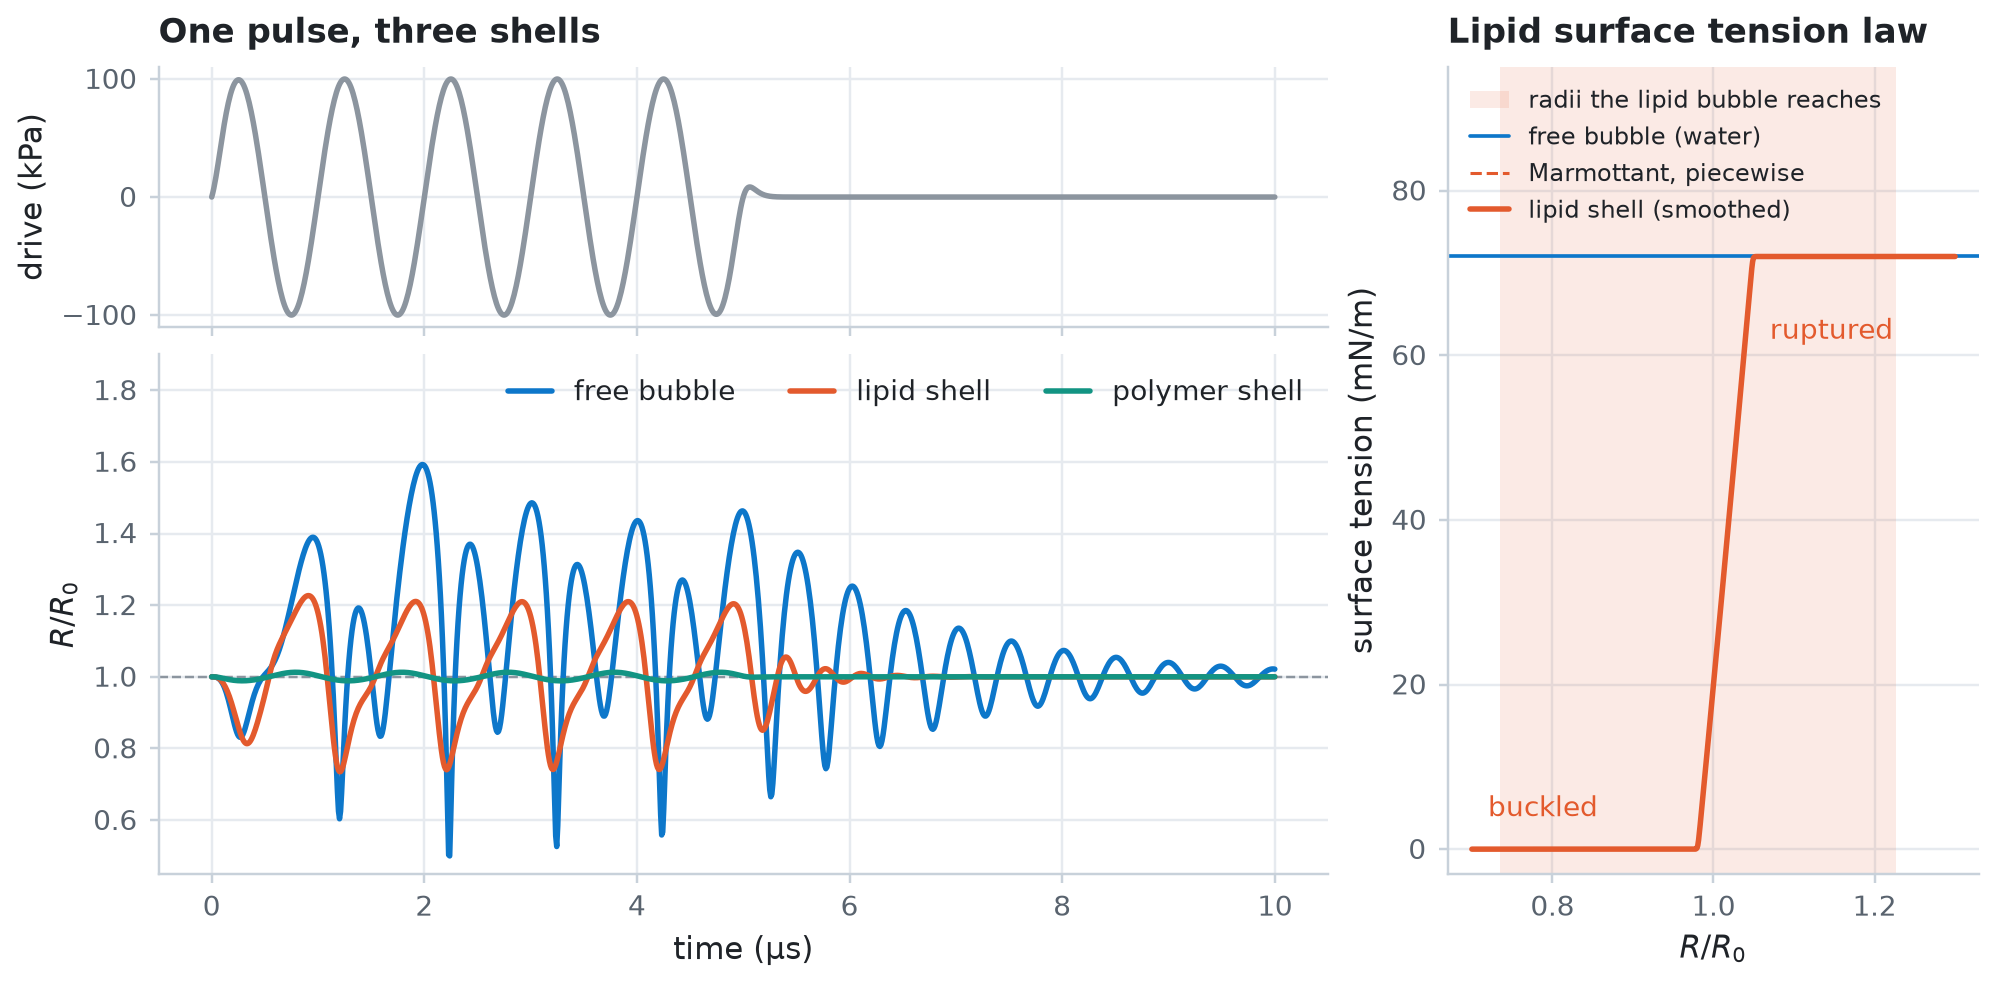

In [3]:
lipid = presets["lipid shell"].eom
R0 = lipid.R0
ratio = jnp.linspace(0.7, 1.3, 600)
states = BubbleState(R=ratio * R0, R0=jnp.full_like(ratio, R0))
sigma_smooth = lipid.shell.sigma(states)
piecewise = MarmottantSurfaceTension(
    R_buckle_ratio=lipid.shell.sigma.R_buckle_ratio,
    chi=lipid.shell.sigma.chi,
    sigma_rupture=lipid.shell.sigma.sigma_rupture,
)
sigma_piecewise = piecewise(states)

fig = plt.figure(figsize=(9.0, 4.4))
grid = fig.add_gridspec(2, 2, width_ratios=[2.2, 1], height_ratios=[1, 2])
ax_p = fig.add_subplot(grid[0, 0])
ax_r = fig.add_subplot(grid[1, 0], sharex=ax_p)
ax_s = fig.add_subplot(grid[:, 1])

drive = runs["free bubble"]
ax_p.plot(drive.ts * 1e6, drive.driving_pressure / 1e3, color=DRIVE)
ax_p.set_ylabel("drive (kPa)")
ax_p.set_title("One pulse, three shells")
ax_p.tick_params(labelbottom=False)
ax_r.axhline(1.0, color=DRIVE, lw=0.8, ls="--")
for colour, (name, run) in zip(["C0", "C1", "C2"], runs.items(), strict=True):
    ax_r.plot(run.ts * 1e6, run.radius / presets[name].eom.R0, color=colour, label=name)
ax_r.set_xlabel("time (µs)")
ax_r.set_ylabel("$R / R_0$")
ax_r.legend(loc="upper right", ncols=3)
ax_r.set_ylim(0.45, 1.9)

lipid_run = runs["lipid shell"]
ax_s.axvspan(
    lipid_run.radius.min() / R0,
    lipid_run.radius.max() / R0,
    color="C1",
    alpha=0.12,
    lw=0,
    label="radii the lipid bubble reaches",
)
ax_s.axhline(0.072 * 1e3, color="C0", lw=1.2, label="free bubble (water)")
ax_s.plot(
    ratio,
    sigma_piecewise * 1e3,
    color="C1",
    lw=1.0,
    ls="--",
    label="Marmottant, piecewise",
)
ax_s.plot(ratio, sigma_smooth * 1e3, color="C1", label="lipid shell (smoothed)")
ax_s.text(0.72, 4, "buckled", color="C1", fontsize=9)
ax_s.text(1.07, 62, "ruptured", color="C1", fontsize=9)
ax_s.set_xlabel("$R / R_0$")
ax_s.set_ylabel("surface tension (mN/m)")
ax_s.set_title("Lipid surface tension law")
ax_s.set_ylim(-3, 95)
ax_s.legend(loc="upper left", fontsize=8)
plt.show()

The polymer shell barely moves: its peak expansion is about 1% at this drive. The lipid-coated bubble oscillates less than the free bubble, mostly because the shell's surface viscosity damps it. Its response is also asymmetric: the shell buckles under compression, where its surface tension drops to zero, so the bubble compresses further (to about 0.74 $R_0$) than it expands (to about 1.23 $R_0$).

## Swap the gas and the medium

The shell is one part; the gas and the medium are the other two. Start from the uncoated bubble and replace one part at a time with `eqx.tree_at`.

For the gas, compare three laws during a violent collapse at 300 kPa:

- An adiabatic polytropic gas, with exponent 1.4 for air, heats up as it compresses, which cushions the collapse.
- An isothermal gas, with exponent 1.0, doesn't heat up, so the bubble collapses much further.
- A van der Waals gas adds a hard core of radius $h$, because the gas molecules can't be compressed below their own volume. Here $h = R_0 / 8.86$, with the same isothermal exponent, so the core alone stops the collapse.

In [4]:
base, _ = free_bubble(R0=2e-6)
collapse_drive = ToneBurst(freq=1e6, pressure=300e3, shape=Sine(), cycle_num=5)
gases = {
    "adiabatic, γ = 1.4": PolytropicGas(gamma=1.4),
    "isothermal, γ = 1.0": PolytropicGas(gamma=1.0),
    "van der Waals, γ = 1.0": VanDerWaalsGas(gamma=1.0, h_frac=1 / 8.86),
}
gas_runs = {}
for name, gas in gases.items():
    model = eqx.tree_at(lambda m: m.gas, base, gas)
    # Collapses last nanoseconds, so record many samples.
    gas_runs[name] = run_simulation(
        model, collapse_drive, save_spec=SaveSpec(num_samples=20_000)
    )
    print(f"{name:24s} smallest R/R0 = {gas_runs[name].radius.min() / base.R0:.3f}")

adiabatic, γ = 1.4       smallest R/R0 = 0.137


isothermal, γ = 1.0      smallest R/R0 = 0.024


van der Waals, γ = 1.0   smallest R/R0 = 0.115


For the medium, compare the peak radius over a range of drive pressures in four surrounding materials:

- Water, a Newtonian liquid with a viscosity of 1 mPa s.
- A soft viscoelastic solid with a shear modulus of 50 kPa, in two models. The Kelvin-Voigt model is linear in the strain; the neo-Hookean model also holds at large strains.
- A shear-thinning liquid, whose viscosity falls as the shear rate rises: a power law with exponent 0.5.

`jax.vmap` runs all the pressures for one medium in a single call. Example 05 covers sweeps in depth.

In [5]:
media = {
    "water": NewtonianMedium(mu=1e-3),
    "Kelvin-Voigt, G = 50 kPa": KelvinVoigtMedium(mu=1e-3, G=50e3),
    "neo-Hookean, G = 50 kPa": NeoHookeanMedium(mu=1e-3, G=50e3),
    # For a power law, mu is the consistency index K [Pa s^n].
    "shear-thinning, n = 0.5": PowerLawMedium(mu=3.0, n_exp=0.5),
}
pressures = jnp.linspace(10e3, 400e3, 12 if QUICK else 40)


def peak_radius(model, pressure):
    pulse = ToneBurst(freq=1e6, pressure=pressure, shape=Sine(), cycle_num=5)
    run = run_simulation(model, pulse, save_spec=SaveSpec(num_samples=2048))
    return run.radius.max() / model.R0, run.converged


peaks = {}
for name, medium in media.items():
    model = eqx.tree_at(lambda m: m.medium, base, medium)
    peak, converged = jax.jit(jax.vmap(peak_radius, in_axes=(None, 0)))(
        model, pressures
    )
    peaks[name] = peak
    print(
        f"{name:26s} peak R/R0 at 400 kPa = {peak[-1]:.2f}, all converged: {bool(converged.all())}"
    )

water                      peak R/R0 at 400 kPa = 4.88, all converged: True


Kelvin-Voigt, G = 50 kPa   peak R/R0 at 400 kPa = 4.48, all converged: True


neo-Hookean, G = 50 kPa    peak R/R0 at 400 kPa = 3.17, all converged: True


shear-thinning, n = 0.5    peak R/R0 at 400 kPa = 4.79, all converged: True


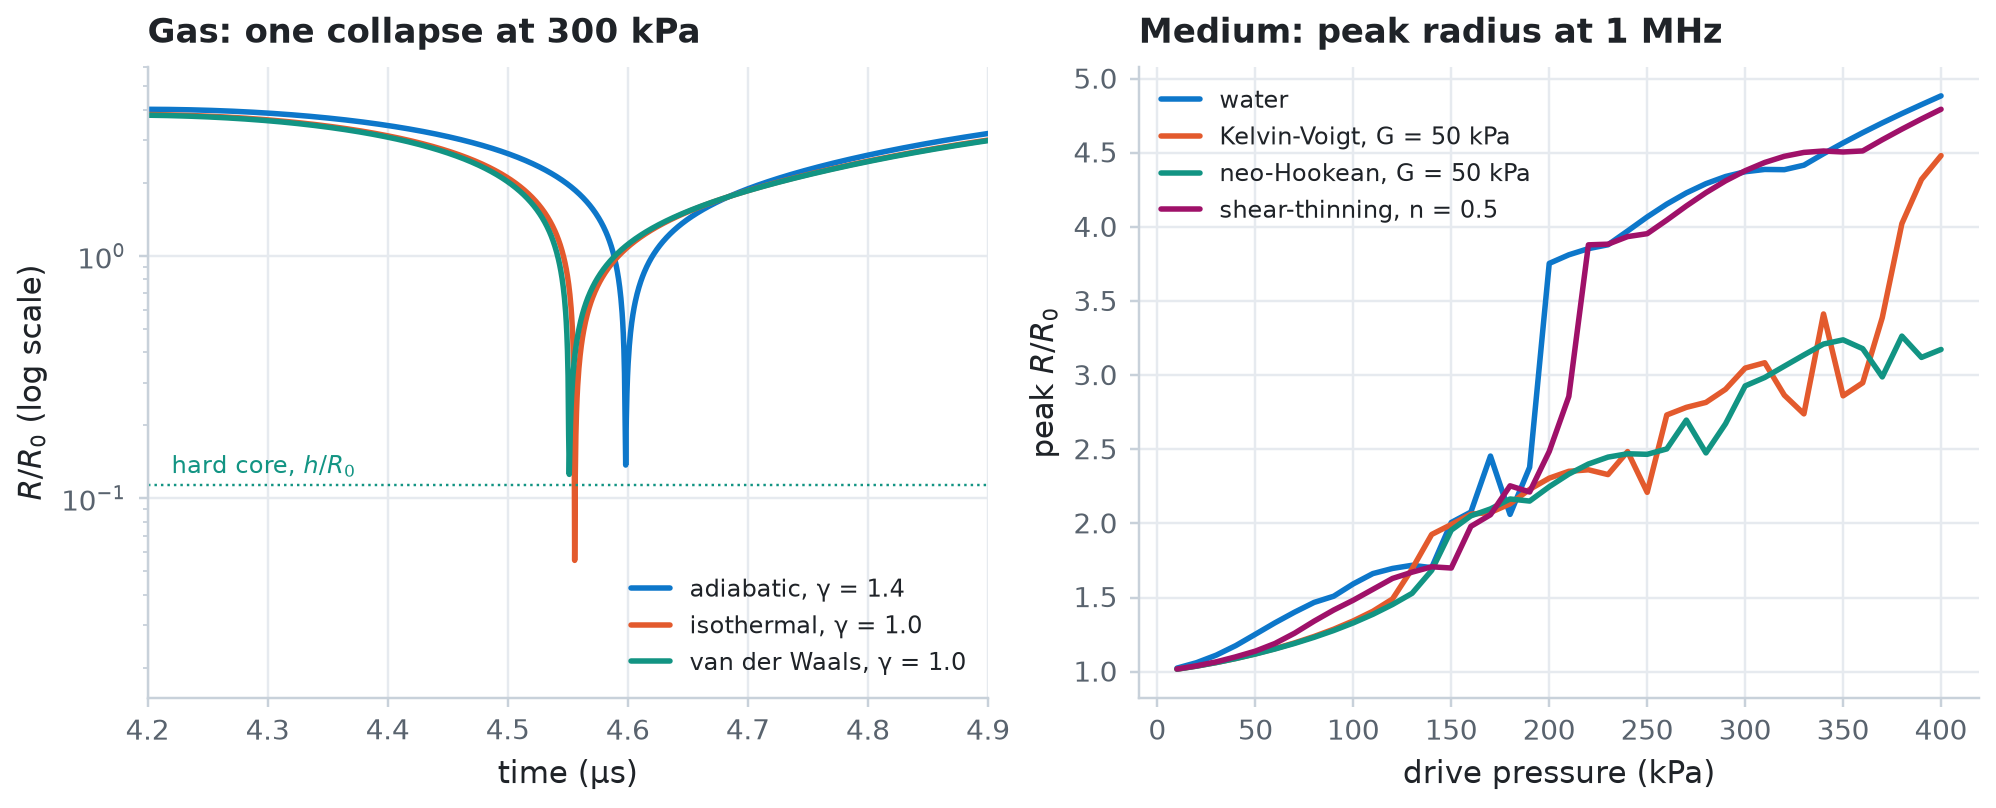

In [6]:
fig, (ax_g, ax_m) = plt.subplots(1, 2, figsize=(9.0, 3.6))
for colour, (name, run) in zip(["C0", "C1", "C2"], gas_runs.items(), strict=True):
    ax_g.plot(run.ts * 1e6, run.radius / base.R0, color=colour, label=name)
ax_g.axhline(1 / 8.86, color="C2", lw=0.8, ls=":")
ax_g.text(4.22, 1 / 8.86 * 1.12, "hard core, $h / R_0$", color="C2", fontsize=8)
ax_g.set_xlim(4.2, 4.9)
ax_g.set_yscale("log")
ax_g.set_ylim(0.015, 6)
ax_g.set_xlabel("time (µs)")
ax_g.set_ylabel("$R / R_0$ (log scale)")
ax_g.set_title("Gas: one collapse at 300 kPa")
ax_g.legend(loc="lower right", fontsize=8)

for colour, (name, peak) in zip(["C0", "C1", "C2", "C3"], peaks.items(), strict=True):
    ax_m.plot(pressures / 1e3, peak, color=colour, label=name)
ax_m.set_xlabel("drive pressure (kPa)")
ax_m.set_ylabel("peak $R / R_0$")
ax_m.set_title("Medium: peak radius at 1 MHz")
ax_m.legend(loc="upper left", fontsize=8)
plt.show()

In water, the peak radius jumps near 200 kPa, where the bubble starts to grow several-fold and collapse violently (example 04). An elastic solid holds the bubble back. Its elastic stress levels off at large expansions, at $4G/3$ in the Kelvin-Voigt model and at $5G/2$ in the neo-Hookean one, so the strongest drives overcome it, the Kelvin-Voigt solid first. The shear-thinning liquid is viscous only at low shear rates; a microbubble shears it so fast that it behaves almost like water.